Cleaned dataset shape: (492, 7)

Final Score
---------------------------------------------
Mean       : 62.88
Median     : 63.80
Mode       : 67.10
Std Dev    : 12.57
Variance   : 158.00
25th %ile  : 54.00
50th %ile  : 63.80
75th %ile  : 70.95

Study Hours
---------------------------------------------
Mean       : 4.99
Median     : 5.02
Mode       : 4.06
Std Dev    : 1.93
Variance   : 3.72
25th %ile  : 3.69
50th %ile  : 5.02
75th %ile  : 6.22


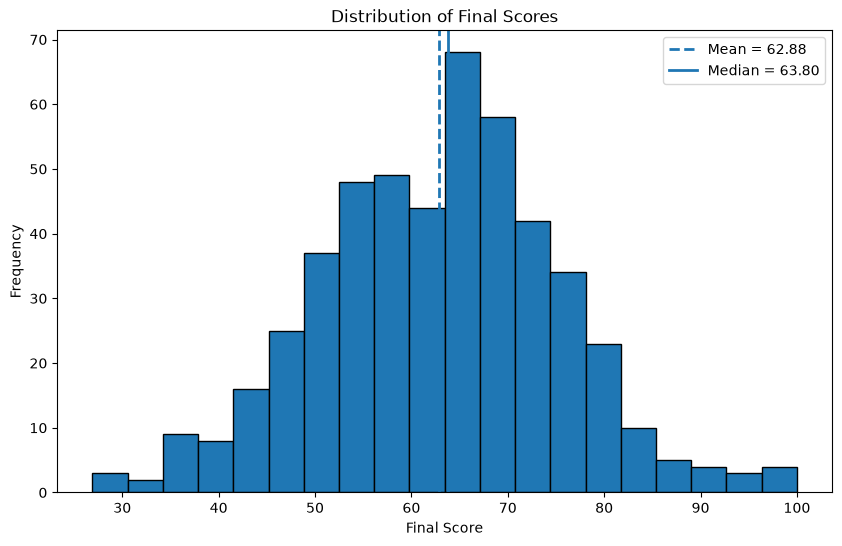


MEAN VS MEDIAN
---------------------------------------------
Mean   : 62.88
Median : 63.80
Difference: -0.92
Mean and median are very close → data is approximately symmetric.

PLAIN-ENGLISH SUMMARY
---------------------------------------------
The average final score is 62.88, while the median score is 63.80. The middle 50% of students have scores between 54.00 and 70.95. The standard deviation is 12.57, which describes how much scores vary around the mean.


In [ ]:
# TASK 01 — DESCRIPTIVE STATISTICS ON A REAL DATASET

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# 1. LOAD AND CLEAN DATA

# Load the student performance dataset
df = pd.read_csv("student_performance.csv")

# Remove missing values
df = df.dropna()

# Remove the impossible 99-hour outlier
# Change the column name if your dataset uses a different name.
df = df[df["study_hours"] != 99]

print("Cleaned dataset shape:", df.shape)

# 2. SELECT TWO COLUMNS

final = df["final_score"]
study = df["study_hours"]

# 3. DESCRIPTIVE STATISTICS FUNCTION

def describe_column(data, name):

    print(f"\n{name}")
    print("-" * 45)

    print(f"Mean       : {data.mean():.2f}")
    print(f"Median     : {data.median():.2f}")

    # Mode can return more than one value
    mode = stats.mode(data, keepdims=True)
    print(f"Mode       : {mode.mode[0]:.2f}")

    # ddof=1 calculates sample standard deviation
    print(f"Std Dev    : {data.std(ddof=1):.2f}")

    # Sample variance
    print(f"Variance   : {data.var(ddof=1):.2f}")

    # 25th, 50th and 75th percentiles
    q25, q50, q75 = np.percentile(data, [25, 50, 75])

    print(f"25th %ile  : {q25:.2f}")
    print(f"50th %ile  : {q50:.2f}")
    print(f"75th %ile  : {q75:.2f}")


# 4. DESCRIPTIVE STATISTICS FOR TWO COLUMNS

describe_column(final, "Final Score")
describe_column(study, "Study Hours")

# 5. HISTOGRAM OF FINAL SCORE

mean_final = final.mean()
median_final = final.median()

plt.figure(figsize=(10, 6))

plt.hist(
    final,
    bins=20,
    edgecolor="black"
)

# Mark the mean
plt.axvline(
    mean_final,
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_final:.2f}"
)

# Mark the median
plt.axvline(
    median_final,
    linestyle="-",
    linewidth=2,
    label=f"Median = {median_final:.2f}"
)

plt.title("Distribution of Final Scores")
plt.xlabel("Final Score")
plt.ylabel("Frequency")
plt.legend()

plt.show()

# ------------------------------------------------------------
# 6. COMPARE MEAN AND MEDIAN
# ------------------------------------------------------------

difference = mean_final - median_final

print("\nMEAN VS MEDIAN")
print("-" * 45)

print(f"Mean   : {mean_final:.2f}")
print(f"Median : {median_final:.2f}")
print(f"Difference: {difference:.2f}")

if abs(difference) < 1:
    print("Mean and median are very close → data is approximately symmetric.")
elif mean_final > median_final:
    print("Mean is above median → data may be right-skewed.")
else:
    print("Mean is below median → data may be left-skewed.")

# 7. BASIC INTERPRETATION

print("\nPLAIN-ENGLISH SUMMARY")
print("-" * 45)

print(
    f"The average final score is {mean_final:.2f}, "
    f"while the median score is {median_final:.2f}. "
    f"The middle 50% of students have scores between "
    f"{np.percentile(final, 25):.2f} and "
    f"{np.percentile(final, 75):.2f}. "
    f"The standard deviation is {final.std(ddof=1):.2f}, "
    f"which describes how much scores vary around the mean."
)

# TASK 01 — Descriptive Statistics on a Real Dataset

### Data Cleaning
- Load `student_performance.csv`.
- Drop missing values.
- Remove the impossible `99-hour` study-hours outlier.
- Perform all calculations on the cleaned dataset.

## Final Score Statistics

Calculate:

- Mean
- Median
- Mode
- Standard deviation
- Variance
- 25th percentile
- 50th percentile
- 75th percentile

### Formulas

**Mean**

\[
\bar{x} = \frac{\sum x}{n}
\]

**Variance**

\[
s^2 = \frac{\sum(x-\bar{x})^2}{n-1}
\]

**Standard Deviation**

\[
s = \sqrt{s^2}
\]

**Percentiles**

- 25th percentile = Q1
- 50th percentile = Median / Q2
- 75th percentile = Q3

---

## Second Column

Perform the same descriptive analysis for at least one additional numerical column.

Example:

**Study Hours**

Calculate:

- Mean
- Median
- Mode
- Standard deviation
- Variance
- 25th percentile
- 50th percentile
- 75th percentile

## Histogram

Create a histogram of the final scores.

The histogram must show:

- Mean
- Median
- Final-score distribution

Compare the positions of the mean and median.

---

# Lookup Questions and Answers

## Q1. When is the median a better summary than the mean?

The median is better when the data contains strong skewness or extreme outliers.

The median is resistant to extreme values, while the mean can be strongly affected by them.

---

## Q2. Why does an outlier pull the mean but not the median?

The mean uses every numerical value in its calculation.

Therefore, an extremely large or small value can move the mean significantly.

The median depends mainly on the middle position of the sorted data, so a single extreme value usually has little effect on it.

---

## Q3. What does it mean if the mean is well above the median?

If:

\[
Mean > Median
\]

by a noticeable amount, the distribution is likely **right-skewed (positively skewed)**.

This usually means that some relatively large values are pulling the mean upward.

## Plain-English Summary

The final score data is summarised using measures of central tendency, spread, and position. The mean and median are compared to understand the shape of the distribution, while the standard deviation and variance describe how much the scores vary. The 25th and 75th percentiles identify the range containing the middle 50% of observations.
